# Semi-Symbolic Attention Mechanism

In [44]:
import spacy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gensim.downloader as api
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder

# Pseudo-Training of $W_q$ and $W_k$ Based on Linguistic Features

## Load Pretrained Embeddings (GloVe)

In [2]:
glove_model = api.load("glove-wiki-gigaword-100")  # 100-dim embeddings
embedding_dim = 100

## Load and Annotate Corpus

In [3]:
nlp = spacy.load("en_core_web_sm")

In [45]:
corpus = [
    "The cat sat on the mat.",
    "She sells sea shells by the seashore.",
    "The quick brown fox jumps over the lazy dog.",
    "A stitch in time saves nine.",
    "Knowledge is power."
]

In [46]:
token_data = []
for doc in nlp.pipe(corpus):
    for token in doc:
        if not token.is_punct and token.text.lower() in glove_model:
            token_data.append({
                'token': token.text.lower(),
                'pos': token.pos_,
                'dep': token.dep_,
                'embedding': glove_model[token.text.lower()]
            })

## Aggregate Embeddings

In [47]:
TOKEN_DF = pd.DataFrame(token_data)

In [34]:
print("Aggregating by POS and DEP...")
pos_groups = TOKEN_DF.groupby('pos')['embedding'].apply(lambda x: np.mean(np.stack(x), axis=0))
dep_groups = TOKEN_DF.groupby('dep')['embedding'].apply(lambda x: np.mean(np.stack(x), axis=0))

Aggregating by POS and DEP...


In [35]:
pos_groups

pos
ADJ      [-0.24159001, -0.17457634, -0.042539995, -0.60...
ADP      [-0.15935424, -0.10315001, 0.39583248, 0.01260...
AUX      [-0.54264, 0.41476, 1.0322, -0.40244, 0.46691,...
DET      [-0.076971665, -0.196724, 0.60339004, -0.36200...
NOUN     [-0.24925439, 0.10814639, 0.18695569, -0.39656...
NUM      [0.17363, 0.37955, 0.1324, -0.35237, 0.63895, ...
PRON     [0.31436, 0.15312, 0.18259, -0.09589, 0.13195,...
PROPN    [0.37873, 0.29093, 0.33448, 0.81958, 0.02157, ...
VERB     [0.24034014, 0.4813325, 0.29796252, -0.0330849...
Name: embedding, dtype: object

In [8]:
dep_groups

dep
ROOT        [0.08374412, 0.468018, 0.44481, -0.106956005, ...
amod        [-0.24159001, -0.17457634, -0.042539995, -0.60...
attr        [-0.040623, 0.12911, 0.92652, -0.072253, 0.438...
compound    [-0.58496, 0.036937, 0.64991, 0.14417, 0.07663...
det         [-0.076971665, -0.196724, 0.60339004, -0.36200...
dobj        [-0.460185, 0.52963, -0.148535, -0.1575775, -0...
nsubj       [0.19600001, -0.025348002, 0.095936015, -0.118...
pobj        [-0.26496774, 0.20162424, 0.18999672, -0.68983...
prep        [-0.15935424, -0.10315001, 0.39583248, 0.01260...
Name: embedding, dtype: object

## Dimensionality Reduction to Common $d_k$

In [ ]:
# d_k = 32 <- THIS DOES NOT WORK
d_k = 9 # This is just the number of pos and dep features 

# Stack embeddings into matrices
POS_matrix = np.stack(pos_groups.values)
DEP_matrix = np.stack(dep_groups.values)

In [10]:
pd.DataFrame(POS_matrix)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.241590,-0.174576,-0.042540,-0.603310,-0.384307,0.141736,0.046363,0.240824,-0.414733,-0.252353,...,0.187884,-0.093457,-0.349070,0.086033,-0.436775,-0.261075,-0.555557,-0.086216,-0.249715,0.042920
1,-0.159354,-0.103150,0.395832,0.012603,0.282106,0.383080,-0.153543,0.259662,-0.493960,0.076349,...,-0.142775,-0.141811,-0.607008,0.566306,-0.501913,0.133498,-0.270052,-0.116783,0.841542,-0.281913
2,-0.542640,0.414760,1.032200,-0.402440,0.466910,0.218160,-0.074864,0.473320,0.080996,-0.220790,...,-0.325280,-0.134600,-0.413140,0.334350,-0.007241,0.322530,-0.044219,-1.296900,0.762170,0.463490
3,-0.076972,-0.196724,0.603390,-0.362000,0.176710,0.155316,-0.266992,0.357230,-0.528937,0.163594,...,0.108847,0.000575,-0.395753,0.725491,-0.618074,-0.473118,-0.435382,-0.203633,0.795978,0.264920
4,-0.249254,0.108146,0.186956,-0.396567,-0.190343,0.012846,0.128965,0.174602,-0.134471,-0.128601,...,0.056660,-0.094031,-0.002160,0.078634,-0.408759,-0.205194,-0.295885,-0.028330,0.445355,-0.064172
5,0.173630,0.379550,0.132400,-0.352370,0.638950,0.474420,0.584400,0.634030,-1.119200,0.008226,...,0.006063,0.114360,-0.396980,-0.259220,-1.195200,0.289140,-0.497600,0.200180,0.375620,-0.298230
6,0.314360,0.153120,0.182590,-0.095890,0.131950,0.442820,-0.140140,0.848790,0.570540,0.202120,...,0.012477,-0.742300,0.957030,0.410570,-0.533520,0.657470,-0.564920,-0.042725,0.060967,0.743450
7,0.378730,0.290930,0.334480,0.819580,0.021570,-0.339020,-0.187860,-0.819970,0.219170,0.329120,...,-0.023005,-0.312780,0.274340,0.340400,0.482210,-0.142430,-0.387730,-1.346000,0.178630,0.950680
8,0.240340,0.481333,0.297963,-0.033085,0.218812,0.181355,-0.031786,0.264297,-0.534637,-0.340998,...,0.096052,-0.237185,0.303110,-0.129915,-0.587788,-0.014114,-0.041170,0.017680,0.322190,0.004597


In [28]:
pd.DataFrame(DEP_matrix)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.083744,0.468018,0.444810,-0.106956,0.268432,0.188716,-0.040401,0.306102,-0.411511,-0.316956,...,0.011786,-0.216668,0.159860,-0.037062,-0.471678,0.053214,-0.041780,-0.245236,0.410186,0.096376
1,-0.241590,-0.174576,-0.042540,-0.603310,-0.384307,0.141736,0.046363,0.240824,-0.414733,-0.252353,...,0.187884,-0.093457,-0.349070,0.086033,-0.436775,-0.261075,-0.555557,-0.086216,-0.249715,0.042920
2,-0.040623,0.129110,0.926520,-0.072253,0.438280,-0.377620,-0.275000,-0.097944,-0.176800,0.382790,...,-0.164830,-0.590480,-0.585210,0.339460,-1.134600,-0.430890,-0.045838,-0.958420,1.088400,-0.090499
3,-0.584960,0.036937,0.649910,0.144170,0.076632,-0.841650,-0.101190,-0.014832,-0.451070,0.066418,...,0.118430,-0.182100,-0.290800,-0.322840,-0.315010,0.724960,-1.702100,0.071790,0.155780,-0.069859
4,-0.076972,-0.196724,0.603390,-0.362000,0.176710,0.155316,-0.266992,0.357230,-0.528937,0.163594,...,0.108847,0.000575,-0.395753,0.725491,-0.618074,-0.473118,-0.435382,-0.203633,0.795978,0.264920
5,-0.460185,0.529630,-0.148535,-0.157577,-0.025385,0.553595,0.868750,0.401455,-0.402085,0.449373,...,0.260582,0.392710,-0.314095,-0.062100,-0.996945,0.162203,-0.685705,0.468735,0.686610,0.128425
6,0.196000,-0.025348,0.095936,-0.118359,-0.033063,0.003010,0.078438,0.091274,0.061363,-0.200865,...,0.050270,-0.343266,0.370459,0.094108,-0.132086,-0.218370,-0.223408,-0.208482,0.149173,0.244698
7,-0.264968,0.201624,0.189997,-0.689830,-0.352448,0.200927,-0.051863,0.315592,-0.137244,-0.272543,...,-0.040995,-0.044384,0.116174,0.228784,-0.307543,-0.193597,-0.043178,-0.120069,0.426375,-0.141451
8,-0.159354,-0.103150,0.395832,0.012603,0.282106,0.383080,-0.153543,0.259662,-0.493960,0.076349,...,-0.142775,-0.141811,-0.607008,0.566306,-0.501913,0.133498,-0.270052,-0.116783,0.841542,-0.281913


In [ ]:
# Reduce dimensions
print("Reducing dimensions with SVD...")
pos_svd = TruncatedSVD(n_components=d_k).fit(POS_matrix)
dep_svd = TruncatedSVD(n_components=d_k).fit(DEP_matrix)

In [ ]:
POS_reduced = pos_svd.transform(POS_matrix)  # (n_pos, d_k)
DEP_reduced = dep_svd.transform(DEP_matrix)  # (n_dep, d_k)

Reducing dimensions with SVD...


In [49]:
pd.DataFrame(POS_reduced)

,0,1,2,3,4,5,6,7,8
0,2.449067,-0.259395,0.926865,0.174090,2.534958,-0.770880,-0.760344,-0.463090,-0.052830
1,4.935031,-0.735204,-0.953282,0.648382,-0.556379,-1.111744,0.896096,-1.039112,0.335735
2,5.125448,0.916156,0.347913,2.190939,-0.078770,1.886384,-0.280360,-0.171980,0.148311
3,5.234675,-0.299820,-1.125506,0.971131,-0.305817,-0.999417,-0.258968,0.846088,-0.933168
4,2.277333,-0.300532,0.222642,0.356697,0.711138,-0.393340,0.557538,1.085475,1.118015
5,3.848894,-2.790236,-1.535575,-1.766076,-0.123507,0.905966,-0.704220,-0.006846,0.268934
6,5.237452,0.563237,3.030289,-1.384127,-1.160139,-0.379728,-0.247978,0.027089,0.019110
7,3.024745,3.711218,-1.749092,-1.609775,0.436230,0.105181,0.036435,-0.026333,0.092647
8,2.002478,-0.806183,0.682028,-0.916690,1.075964,1.007228,1.429120,0.103275,-0.681317


In [50]:
pd.DataFrame(DEP_reduced)

,0,1,2,3,4,5,6,7,8
0,2.411080,-0.517525,-0.896450,-0.224746,0.975046,-0.834945,1.428770,-0.085283,-0.715676
1,2.395050,-0.273772,-1.893635,-1.066437,1.217788,1.640961,-0.129574,0.207395,-0.017812
2,4.418397,-2.807597,2.702679,-0.642367,0.860808,0.096845,-0.206220,-0.033089,0.034527
3,4.444427,3.994127,1.309370,-1.398262,-0.147956,0.078850,0.203176,-0.042616,0.029238
4,5.224227,-0.613342,-0.691241,0.660128,-1.492339,0.351284,-0.292423,-1.055319,-0.561832
5,3.104259,1.387417,0.012126,2.795993,1.555746,-0.113656,-0.346482,-0.099382,0.192683
6,2.480722,-0.521365,-1.405223,-1.044782,0.277748,-0.965524,-0.165903,-0.614175,1.148764
7,2.187206,0.090481,-0.897413,-0.717773,0.163315,-1.023944,-1.235428,0.727812,-0.692119
8,4.983473,-0.692337,-0.409709,0.839242,-1.302854,0.091703,0.519830,1.163439,0.499003


## Fit $W_q$ and $W_k$

In [11]:
# Encode POS and DEP labels to integers
pos_encoder = LabelEncoder().fit(TOKEN_DF['pos'])
dep_encoder = LabelEncoder().fit(TOKEN_DF['dep'])

In [33]:
# dep_encoder.classes_

In [12]:
# Build training data
E_tokens = np.stack(TOKEN_DF['embedding'].values)  # (n_tokens, embedding_dim)
POS_targets = pos_encoder.transform(TOKEN_DF['pos'])  # (n_tokens,)
DEP_targets = dep_encoder.transform(TOKEN_DF['dep'])

In [59]:
set(POS_targets)

{0, 1, 2, 3, 4, 5, 6, 7, 8}

In [16]:
# Map targets to reduced vectors
POS_target_vectors = POS_reduced[POS_targets]  # (n_tokens, d_k)
DEP_target_vectors = DEP_reduced[DEP_targets]

In [18]:
# Convert to torch tensors
E_tokens_torch = torch.tensor(E_tokens, dtype=torch.float32)
POS_targets_torch = torch.tensor(POS_target_vectors, dtype=torch.float32)
DEP_targets_torch = torch.tensor(DEP_target_vectors, dtype=torch.float32)

In [19]:
# Linear mappings
W_q = nn.Linear(embedding_dim, d_k, bias=False)
W_k = nn.Linear(embedding_dim, d_k, bias=False)

In [20]:
optimizer = torch.optim.Adam(list(W_q.parameters()) + list(W_k.parameters()), lr=0.01)
loss_fn = nn.MSELoss()

In [21]:
# Training pseudo W_q and W_k ...
for epoch in range(500):
    optimizer.zero_grad()
    pred_q = W_q(E_tokens_torch)
    pred_k = W_k(E_tokens_torch)
    loss_q = loss_fn(pred_q, POS_targets_torch)
    loss_k = loss_fn(pred_k, DEP_targets_torch)
    loss = loss_q + loss_k
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 4.5785
Epoch 50, Loss: 0.0403
Epoch 100, Loss: 0.0042
Epoch 150, Loss: 0.0007
Epoch 200, Loss: 0.0001
Epoch 250, Loss: 0.0000
Epoch 300, Loss: 0.0000
Epoch 350, Loss: 0.0000
Epoch 400, Loss: 0.0000
Epoch 450, Loss: 0.0000


# Apply Models

## Define an Attention Class

In [74]:
class PseudoAttention(nn.Module):
    
    def __init__(self, pretrained_Wq, pretrained_Wk, embedding_dim, d_k):
        super().__init__()
        self.W_q = nn.Linear(embedding_dim, d_k, bias=False)
        self.W_k = nn.Linear(embedding_dim, d_k, bias=False)
        self.W_v = nn.Linear(embedding_dim, d_k, bias=False)  # Random

        # Load trained weights
        self.W_q.weight.data = pretrained_Wq.weight.data.clone()
        self.W_k.weight.data = pretrained_Wk.weight.data.clone()
        
    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        
        scores = Q @ K.transpose(-2, -1) / np.sqrt(Q.size(-1))
        weights = F.softmax(scores, dim=-1)
        output = weights @ V
        return output, weights, scores

## Test with a Sentence

In [75]:
# Test sentence
test_sentence = "Dogs bark loudly at strangers."

# Tokenize and embed
test_doc = nlp(test_sentence)
test_tokens = [token.text.lower() for token in test_doc if not token.is_punct and token.text.lower() in glove_model]
test_embeddings = np.stack([glove_model[t] for t in test_tokens])
test_embeddings_torch = torch.tensor(test_embeddings, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, embed_dim)

In [73]:
# test_embeddings

In [24]:
# Instantiate module
attention_module = PseudoAttention(W_q, W_k, embedding_dim=100, d_k=32)

In [25]:
# Forward pass
contextualized_output, attention_weights, raw_scores = attention_module(test_embeddings_torch)

## Visualize Results

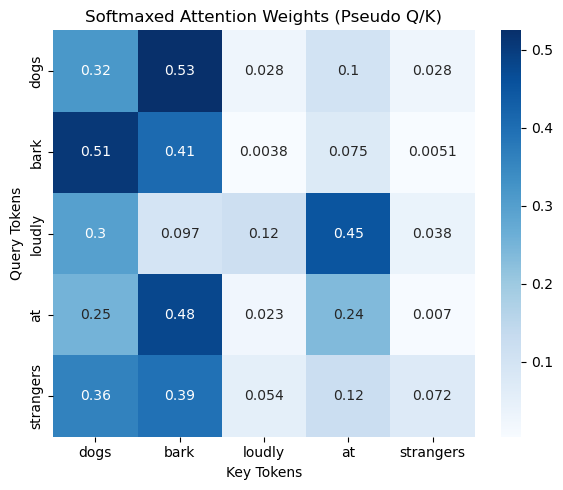

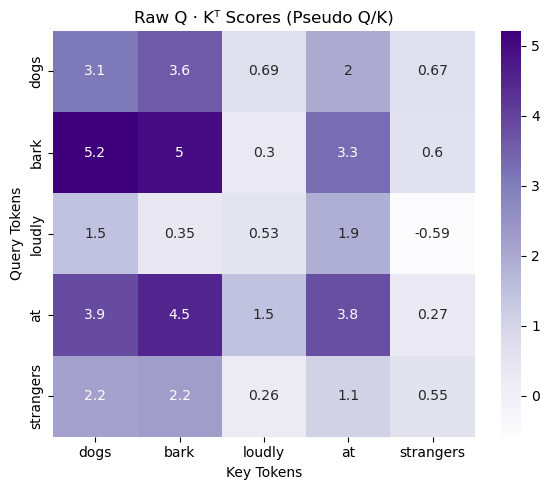

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

tokens = test_tokens

# Heatmap of softmaxed attention
plt.figure(figsize=(6, 5))
sns.heatmap(attention_weights.squeeze(0).detach().numpy(), annot=True, cmap="Blues", xticklabels=tokens, yticklabels=tokens)
plt.title("Softmaxed Attention Weights (Pseudo Q/K)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.tight_layout()
plt.show()

# (Optional) Heatmap of raw dot products (before softmax)
plt.figure(figsize=(6, 5))
sns.heatmap(raw_scores.squeeze(0).detach().numpy(), annot=True, cmap="Purples", xticklabels=tokens, yticklabels=tokens)
plt.title("Raw Q · Kᵀ Scores (Pseudo Q/K)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.tight_layout()
plt.show()